# Heart Disease Classifier from Scratch

In this project, I build a simple heart disease classification model from scratch using NumPy.

The goal is not to create a medical diagnostic tool. The goal is to understand how binary classification works by implementing logistic regression step by step.

This project covers:

- loading a real-world dataset
- understanding the features and target variable
- preprocessing the data
- implementing logistic regression from scratch
- evaluating the model using classification metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plots_dir = Path("../assets/plots")
plots_dir.mkdir(parents=True, exist_ok=True)

from ucimlrepo import fetch_ucirepo

In [2]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset shape: (303, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')


## Target Variable

The original target column in this dataset is `num`.

The values mean:

- 0: no heart disease presence
- 1, 2, 3, 4: heart disease presence

For this project, I will convert the target into a binary classification problem:

- 0: no heart disease presence
- 1: heart disease presence

In [4]:
df["num"].value_counts().sort_index()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [5]:
df["target"] = (df["num"]>0).astype(int)

df[["num", "target"]].head(10)

,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0
5,0,0
6,3,1
7,0,0
8,2,1
9,1,1


In [6]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

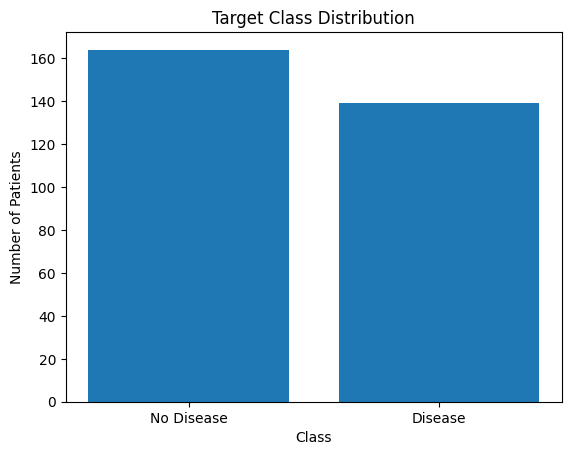

In [7]:
target_counts = df["target"].value_counts().sort_index()

plt.bar(["No Disease", "Disease"], target_counts)
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.title("Target Class Distribution")
plt.show()

## Class Distribution

Before training a classification model, it is important to check how balanced the target classes are.

If one class is much more common than the other, accuracy alone can become misleading. For example, if 90% of the data belonged to one class, a model could get high accuracy just by predicting that class repeatedly.

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
target      0
dtype: int64

In [9]:
df_clean = df.dropna().copy()
print(df_clean.isnull().sum())

print("\nOriginal shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
target      0
dtype: int64

Original shape: (303, 15)
Cleaned shape: (297, 15)


## Handling Missing Values

Some rows contain missing values.

For this first version of the project, I remove rows with missing values to keep the preprocessing simple and focus on implementing logistic regression from scratch.

In a more advanced version, I could experiment with imputation instead of dropping rows.

In [10]:
df_clean.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


## Preparing Features and Labels

Now that the dataset has been cleaned, the next step is to separate the data into two parts:

- **Features**, also called inputs
- **Labels**, also called targets or outputs

The features are the patient measurements that the model will use to make predictions. These include columns like age, cholesterol, resting blood pressure, maximum heart rate, and other medical indicators.

The label is the value the model is trying to predict. In this project, the label is the binary `target` column:

- `0` means no heart disease presence
- `1` means heart disease presence

This separation is important because the model should learn patterns from the input features and compare its predictions against the correct target labels.

In [11]:
X_df = df_clean.drop(columns=["num", "target"])
y_df = df_clean["target"]

print("Features shape: ", X_df.shape)
print("Target shape: ", y_df.shape)

Features shape:  (297, 13)
Target shape:  (297,)


### Separating the Input Features from the Target

The cleaned dataset contains both the input columns and the target columns.

The original target column is `num`, which contains values from 0 to 4. Earlier, I converted this into a simpler binary column called `target`.

For model training, I remove both `num` and `target` from the input features:

- `num` is removed because it is the original answer column
- `target` is removed because it is the final answer column the model is trying to predict

If the model were allowed to see the answer column while training, it would not actually learn useful patterns. It would simply have access to the correct answer. This is called **data leakage**.

After removing the target columns:

- `X_df` contains only the input features
- `y_df` contains the correct labels

In [12]:
X_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


### Understanding the Feature Table

`X_df` is a pandas DataFrame containing only the input features.

Each row represents one patient.

Each column represents one feature about that patient.

For example, one row may contain information such as:

- age
- sex
- chest pain type
- resting blood pressure
- cholesterol
- fasting blood sugar
- maximum heart rate
- exercise-induced angina

These values will be used by the logistic regression model to estimate whether heart disease is present or not.

In [13]:
y_df.head()

0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

### Understanding the Target Column

`y_df` contains the correct answer for each patient.

The values are binary:

- `0` means no heart disease presence
- `1` means heart disease presence

This is why the problem is called a **binary classification problem**. The model is not predicting a continuous number. It is choosing between two possible classes.

## Converting Pandas DataFrames to NumPy Arrays

So far, the data has been stored in pandas objects.

Pandas is useful for viewing, cleaning, and exploring tabular data. However, the actual machine learning model will be implemented using NumPy.

This means I need to convert the feature table and target column into NumPy arrays.

The conversion is:

- `X_df` → `X`
- `y_df` → `y`

After conversion:

- `X` will store the input features as a NumPy array
- `y` will store the target labels as a NumPy array

This is important because logistic regression uses mathematical operations such as dot products, vectorized calculations, gradients, and matrix operations. NumPy is designed for these operations.

In [14]:
X = X_df.to_numpy(dtype=float)
y = y_df.to_numpy(dtype=float)

### Checking the Converted Data

After converting the data to NumPy arrays, I check the types and shapes.

The shape of `X` should be:

`(number of examples, number of features)`

The shape of `y` should be:

`(number of examples,)`

In this dataset, each example is one patient.

In [15]:
print("X type:", type(X))
print("y type:", type(y))

print("\nX shape:", X.shape)
print("y shape:", y.shape)

X type: <class 'numpy.ndarray'>
y type: <class 'numpy.ndarray'>

X shape: (297, 13)
y shape: (297,)


### Interpreting the Shapes

The feature matrix `X` has shape `(297, 13)`.

This means there are:

- 297 training examples available at this stage
- 13 features for each example

The target array `y` has shape `(297,)`.

This means there is one correct label for each patient.

So the data is aligned correctly:

- `X[0]` contains the features for the first patient
- `y[0]` contains the correct label for the first patient

In [16]:
print("First patient features:")
print(X[0])

print("\nFirst patient label:")
print(y[0])

First patient features:
[ 63.    1.    1.  145.  233.    1.    2.  150.    0.    2.3   3.    0.
   6. ]

First patient label:
0.0


## Checkpoint

At this stage, the dataset has been prepared for model training.

The main variables are:

- `df_clean`: cleaned pandas DataFrame
- `X_df`: pandas DataFrame containing only input features
- `y_df`: pandas Series containing the binary target labels
- `X`: NumPy array containing input features
- `y`: NumPy array containing target labels

The next step is to split the data into training and testing sets.

The training set will be used to teach the model.

The testing set will be used to evaluate how well the model performs on unseen data.

## Train/Test Split

To evaluate the model properly, I split the dataset into two parts:

- training set: used to train the model
- testing set: used to evaluate the model on unseen data

This helps check whether the model is actually learning useful patterns instead of only memorizing the data.

In [17]:
def train_test_split(X, y, test_size=0.2, random_state=42):
    
    np.random.seed(random_state)
    m = X.shape[0]
    indices = np.random.permutation(m)

    test_count = int(m*test_size)

    test_indices = indices[:test_count]
    train_indices = indices[test_count:]

    X_test = X[test_indices]
    X_train = X[train_indices]

    y_test = y[test_indices]    
    y_train = y[train_indices]

    return X_train, X_test, y_train, y_test



### Applying the Split

I use an 80/20 split, meaning around 80% of the data is used for training and 20% is kept for testing.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (238, 13)
X_test shape: (59, 13)
y_train shape: (238,)
y_test shape: (59,)


## Feature Normalization

The dataset contains features with very different scales.

For example, cholesterol values can be much larger than values like chest pain type or fasting blood sugar.

To make gradient descent work better, I normalize the features using z-score normalization:

normalized value = (value - mean) / standard deviation

The mean and standard deviation are calculated from the training set only, then applied to both the training and testing sets.

In [19]:
def normalize_features(X_train, X_test):
    mean = np.mean(X_train, axis=0)
    sd = np.std(X_train, axis = 0)

    X_train_norm = (X_train-mean)/sd
    X_test_norm = (X_test-mean)/sd

    return X_train_norm, X_test_norm, mean, sd

### Applying Normalization

The model will be trained on the normalized features instead of the original raw feature values.

In [20]:
X_train_norm, X_test_norm, mean, std = normalize_features(X_train, X_test)

print("Training features after normalization:")
print("Mean:", np.round(np.mean(X_train_norm, axis=0), 2))
print("Standard deviation:", np.round(np.std(X_train_norm, axis=0), 2))

Training features after normalization:
Mean: [-0.  0.  0. -0. -0. -0. -0.  0.  0.  0.  0. -0. -0.]
Standard deviation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [21]:
print("First training example before normalization:")
print(X_train[0])

print("\nFirst training example after normalization:")
print(np.round(X_train_norm[0], 2))

First training example before normalization:
[ 59.    1.    1.  178.  270.    0.    2.  145.    0.    4.2   3.    0.
   7. ]

First training example after normalization:
[ 0.49  0.65 -2.25  2.5   0.41 -0.44  0.96 -0.15 -0.73  2.74  2.24 -0.72
  1.13]


## Checkpoint

The data is now ready for logistic regression.

At this stage:

- `X_train_norm` contains the normalized training features
- `X_test_norm` contains the normalized testing features
- `y_train` contains the training labels
- `y_test` contains the testing labels

Next, I will implement logistic regression from scratch.

## Logistic Regression from Scratch

Logistic regression is used for binary classification problems.

In this project, the model predicts a probability between 0 and 1:

- closer to 0 means the model predicts no heart disease presence
- closer to 1 means the model predicts heart disease presence

The main steps are:

1. compute a linear score using features, weights, and bias
2. pass that score through the sigmoid function
3. calculate the cost
4. use gradient descent to update the weights and bias

### The Sigmoid Function

The sigmoid function converts any real number into a value between 0 and 1.

This makes it useful for classification because the output can be interpreted as a probability.

In [22]:
def sigmoid(z):
    """
    Compute the sigmoid of z.

    Parameters:
        z: a number, list, or NumPy array

    Returns:
        sigmoid value between 0 and 1
    """
    f = 1/(1+np.exp(-z))
    
    return f

### Model Prediction

For each patient, the model first computes a linear score:

z = Xw + b

Then it applies the sigmoid function:

prediction = sigmoid(z)

The result is a probability. Later, probabilities greater than or equal to 0.5 will be classified as 1, while probabilities below 0.5 will be classified as 0.

In [23]:
def predict_proba(X, w, b):
    """
    Predict probabilities using logistic regression.

    Parameters:
        X: feature matrix
        w: weights
        b: bias

    Returns:
        predicted probabilities
    """
    z = np.dot(X, w) + b
    prob = sigmoid(z)

    return prob

### Cost Function

The cost function measures how wrong the model's predictions are.

For logistic regression, we use binary cross-entropy loss.

The model is penalized when:

- the true label is 1 but the predicted probability is low
- the true label is 0 but the predicted probability is high

Gradient descent will try to minimize this cost.

In [24]:
def compute_cost(X, y, w, b):
    """
    Compute logistic regression cost.

    Parameters:
        X: feature matrix
        y: true labels
        w: weights
        b: bias

    Returns:
        cost value
    """
    m = X.shape[0]
    
    f = predict_proba(X, w, b)

    f = np.clip(f, 1e-15, 1-1e-15)
    cost = np.sum(y*np.log(f) + (1-y)*np.log(1-f)) / -m
    
    return cost

### Gradients

Gradients tell us how the weights and bias should change to reduce the cost.

For logistic regression:

- `dj_dw` tells us how to update the weights
- `dj_db` tells us how to update the bias

These gradients are used inside gradient descent.

In [25]:
def compute_gradient(X, y, w, b):
    """
    Compute gradients for logistic regression.

    Parameters:
        X: feature matrix
        y: true labels
        w: weights
        b: bias

    Returns:
        dj_dw: gradient for weights
        dj_db: gradient for bias
    """
    m = X.shape[0]
    f = predict_proba(X, w, b)

    dj_dw = np.dot(f-y, X) / m
    dj_db = np.sum(f-y) / m
   
    return dj_dw, dj_db

### Gradient Descent

Gradient descent updates the weights and bias repeatedly.

Each update moves the parameters in the direction that reduces the cost.

The learning rate controls how large each update step is.

In [26]:
def gradient_descent(X, y, w, b, alpha, num_iters):
    """
    Run gradient descent for logistic regression.

    Parameters:
        X: feature matrix
        y: true labels
        w: initial weights
        b: initial bias
        alpha: learning rate
        num_iters: number of iterations

    Returns:
        w: learned weights
        b: learned bias
        cost_history: list of cost values
    """
    cost_history = []
    
    for i in range(num_iters):
       dj_dw, dj_db = compute_gradient(X, y, w, b)

       w = w - alpha*dj_dw
       b = b - alpha*dj_db

       cost_history.append(compute_cost(X, y, w, b))
    
    return w, b, cost_history

## Initializing the Model

Before training, the weights and bias need starting values.

I initialize:

- all weights as 0
- bias as 0

Gradient descent will then update these values during training.

In [27]:
n_features = X_train_norm.shape[1]

w_init = np.zeros(n_features)
b_init = 0

print("Initial weights shape:", w_init.shape)
print("Initial bias:", b_init)

Initial weights shape: (13,)
Initial bias: 0


## Training the Model

Now I train the logistic regression model using gradient descent.

The model starts with zero weights and zero bias. During training, gradient descent updates these values to reduce the cost.

In [28]:
initial_cost = compute_cost(X_train_norm, y_train, w_init, b_init)

print("Initial cost:", initial_cost)

Initial cost: 0.6931471805599453


In [29]:
alpha = 0.01
num_iters = 10000

w_final, b_final, cost_history = gradient_descent(
    X_train_norm,
    y_train,
    w_init,
    b_init,
    alpha,
    num_iters
)

print("Final cost:", cost_history[-1])
print("Final bias:", b_final)
print("Final weights:")
print(w_final)

Final cost: 0.36536323381859154
Final bias: 0.03636614469888904
Final weights:
[-0.08660237  0.66122838  0.42079132  0.44534669  0.34137402 -0.44949903
  0.18662809 -0.49906849  0.46912109  0.2396477   0.22819648  1.22118165
  0.50483678]


### Cost Curve

The cost curve shows whether gradient descent is working.

If the model is learning properly, the cost should decrease over time.

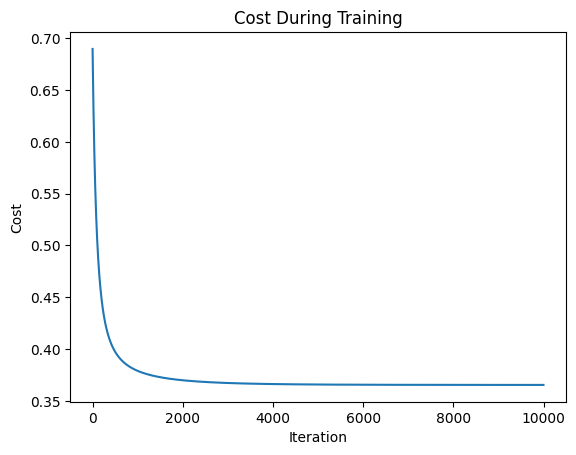

In [30]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Training")

plt.savefig(plots_dir / "cost-history.png", bbox_inches="tight", dpi=300)
plt.show()

## Making Predictions

The trained model outputs probabilities between 0 and 1.

To convert probabilities into final class predictions, I use a threshold of 0.5:

- probability >= 0.5 → predict 1
- probability < 0.5 → predict 0

In [31]:
def predict(X, w, b, threshold=0.5):
    """
    Convert predicted probabilities into class predictions.
    """

    prob = predict_proba(X, w, b)
    prob = (prob >= threshold).astype(int)

    return prob

In [32]:
train_predictions = predict(X_train_norm, w_final, b_final)
test_predictions = predict(X_test_norm, w_final, b_final)

print("First 10 test predictions:")
print(test_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

First 10 test predictions:
[0 0 0 1 0 0 0 1 1 0]

First 10 actual labels:
[0. 1. 0. 1. 0. 0. 0. 0. 1. 0.]


## Model Evaluation

To evaluate the model, I will start with accuracy.

Accuracy measures the percentage of predictions that the model got correct.

In [33]:
def accuracy_score(y_true, y_pred):
    """
    Compute classification accuracy.
    """
    accuracy = np.mean(y_true == y_pred) * 100

    return accuracy

In [34]:
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Training accuracy: {train_accuracy:.2f}%")
print(f"Testing accuracy: {test_accuracy:.2f}%")

Training accuracy: 84.45%
Testing accuracy: 88.14%


### Beyond Accuracy

Accuracy is useful, but it does not tell the full story.

For a classification problem, it is also helpful to look at:

- true positives
- true negatives
- false positives
- false negatives

These values form the confusion matrix.

In [35]:
def confusion_matrix_values(y_true, y_pred):
    """
    Compute true positives, true negatives, false positives, and false negatives.
    """
    tp = np.sum((y_pred == 1) & (y_true == 1))

    tn = np.sum((y_pred == 0) & (y_true == 0))

    fp = np.sum((y_pred == 1) & (y_true == 0))

    fn = np.sum((y_pred == 0) & (y_true == 1))

    return tp, tn, fp, fn

 ### Confusion Matrix Values

The confusion matrix breaks the predictions into four groups:

- true positives: disease correctly predicted as disease
- true negatives: no disease correctly predicted as no disease
- false positives: no disease incorrectly predicted as disease
- false negatives: disease incorrectly predicted as no disease

This is useful because accuracy alone does not show what kinds of mistakes the model is making.

In [36]:
tp, tn, fp, fn = confusion_matrix_values(y_test, test_predictions)

print("True Positives:", tp)
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)

True Positives: 20
True Negatives: 32
False Positives: 3
False Negatives: 4


### Precision, Recall, and F1 Score

Precision tells us how many predicted positive cases were actually positive.

Recall tells us how many actual positive cases the model correctly identified.

F1 score combines precision and recall into one metric.

In [37]:
def precision_score(y_true, y_pred):
   
    tp, tn, fp, fn = confusion_matrix_values(y_true, y_pred)

    denominator = tp + fp

    if denominator == 0:
        return 0
    
    precision = tp / denominator

    return precision

def recall_score(y_true, y_pred):

    tp, tn, fp, fn = confusion_matrix_values(y_true, y_pred)

    denominator = tp + fn

    if denominator == 0:
        return 0
    
    score = tp / denominator

    return score


def f1_score(y_true, y_pred):

    precision =  precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    denominator = precision + recall

    if denominator == 0:
        return 0
    
    f1 = 2 * precision * recall / denominator

    return f1

In [38]:
test_precision = precision_score(y_test, test_predictions)
test_recall = recall_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)

print(f"Test accuracy: {test_accuracy:.2f}%")
print(f"Test precision: {test_precision:.2f}")
print(f"Test recall: {test_recall:.2f}")
print(f"Test F1 score: {test_f1:.2f}")

Test accuracy: 88.14%
Test precision: 0.87
Test recall: 0.83
Test F1 score: 0.85


## Results Summary

The model performs reasonably well on the test set.

Since this is a health-related classification task, accuracy alone is not enough. Precision, recall, and F1 score provide a better view of how the model performs on positive cases.

In [39]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        test_accuracy,
        test_precision * 100,
        test_recall * 100,
        test_f1 * 100
    ]
})

results["Score"] = results["Score"].round(2)

results

,Metric,Score
0,Accuracy,88.14
1,Precision,86.96
2,Recall,83.33
3,F1 Score,85.11


## Confusion Matrix

The confusion matrix shows the exact types of correct and incorrect predictions made by the model.

In [40]:
conf_matrix = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

conf_matrix

,Predicted 0,Predicted 1
Actual 0,32,3
Actual 1,4,20


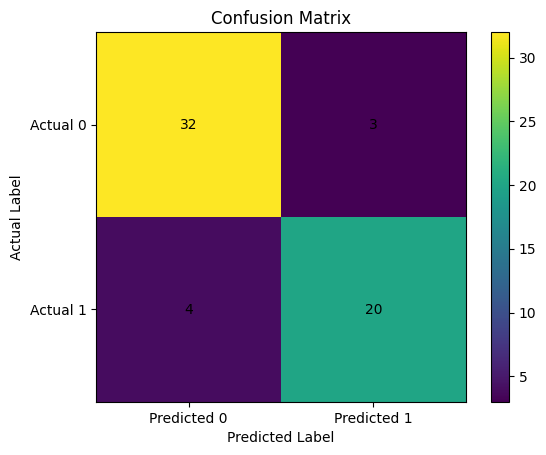

In [41]:
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix.iloc[i, j], ha="center", va="center")

plt.colorbar()

plt.savefig(plots_dir / "confusion-matrix.png", bbox_inches="tight", dpi=300)
plt.show()

## Interpretation

The model achieved strong test accuracy for a simple logistic regression model built from scratch.

The precision score shows that most positive predictions were correct. The recall score shows that the model identified most actual positive cases, although some were still missed.

Because this project uses a small public dataset, the results should be treated as educational rather than medical. The goal is to understand the machine learning workflow and implementation, not to create a diagnostic system.

## Limitations

This project has several limitations:

- the dataset is small
- missing values were dropped instead of imputed
- only logistic regression was used
- no hyperparameter tuning was performed
- the model is not suitable for real medical diagnosis
- no regularization was added

A future version could compare this from-scratch model with scikit-learn, try regularization, and test other classification models.

## What I Learned

In this project, I learned how to:

- prepare a real-world dataset for binary classification
- split data into training and testing sets
- normalize features before training
- implement logistic regression from scratch using NumPy
- train the model using gradient descent
- evaluate classification performance using multiple metrics

This project helped connect the theory of logistic regression with a practical dataset.